# CSS surface-code decoding

This notebook decodes one CSS sector of a small GKP surface code. It is meant as a compact example of the package API, not as a threshold or data-collection script.

In [1]:
using Random
using LinearAlgebra
using LatticeDecoder

Random.seed!(4);

Build a distance-3 surface code and select one CSS sector. For `basis = "X"`, we decode with the `q`-sector check matrix and use the dual `p`-sector generator for corrections.

In [9]:
d = 3
basis = "X"

code = GKP_Surface_Code(d, false);
M = code.code;
logicals = code.logical;

half = div(size(M, 1), 2);
Mqq = M[1:half, 1:half];
Mpp = M[(half + 1):end, (half + 1):end];

if basis == "X"
    H = Mqq
    G = inv(Mpp)
elseif basis == "Z"
    H = Mpp
    G = -inv(Mqq)
else
    error("basis must be either X or Z")
end

logical_check = inv(H);


Draw one Gaussian displacement, run serial belief propagation, then convert the continuous BP estimate into an integer correction.

In [58]:
noise_std = 0.45
max_iter = size(H, 2)
decoder = "lsd"
search_interval = 1.0

error_vector = sample_error(noise_std, size(H, 2));
received = copy(error_vector);

tanner_graph = initialize_tanner_graph(H);
bp_estimate = run_serial_belief_propagation!(
    tanner_graph,
    received,
    noise_std,
    max_iter,
    decoder;
    search_interval = search_interval,
);

decoded_integer_correction = hard_decision(bp_estimate, H);

Check whether the residual displacement is trivial up to the logical lattice.

In [60]:
function is_not_logical_error(logical_check, residual; atol = 1e-5)
    logical_coordinates = logical_check' * residual
    return all(abs(x - round(x)) < atol for x in logical_coordinates)
end

correction = received - G * decoded_integer_correction;
residual = error_vector - correction;
println("BP is correct: ", is_not_logical_error(logical_check, residual))
println("BP + logical is correct: ", is_not_logical_error(logical_check, residual + logicals[1, 1:half]))


BP is correct: false
BP + logical is correct: true


## Small distance sweep

The next cells run a small CSS-sector sweep for `d = 3, 5, 7` over six noise values and plot the observed logical failure rate. This is intentionally small so the notebook remains an example; increase `samples_per_point` for smoother curves.

In [5]:
using Plots

function css_surface_code_sector(d; basis = "X")
    code = GKP_Surface_Code(d, false)
    M = code.code
    half = div(size(M, 1), 2)
    Mqq = M[1:half, 1:half]
    Mpp = M[(half + 1):end, (half + 1):end]

    if basis == "X"
        return Mqq, inv(Mpp)
    elseif basis == "Z"
        return Mpp, -inv(Mqq)
    else
        error("basis must be either X or Z")
    end
end

function css_decode_fails(H, G, noise_std; decoder = "nearest", search_interval = 1.0)
    logical_check = inv(H)
    error_vector = sample_error(noise_std, size(H, 2))
    received = copy(error_vector)
    tanner_graph = initialize_tanner_graph(H)

    bp_estimate = run_serial_belief_propagation!(
        tanner_graph,
        received,
        noise_std,
        size(H, 2),
        decoder;
        search_interval = search_interval,
    )

    decoded_integer_correction = hard_decision(bp_estimate, H)
    correction = received - G * decoded_integer_correction
    residual = error_vector - correction

    return !is_not_logical_error(logical_check, residual)
end

css_decode_fails (generic function with 1 method)

In [6]:
distances = [3, 5, 7]
sigmas = collect(range(0.3, 0.8; length = 6)) ./ sqrt(2 * pi)
samples_per_point = 50_000

failure_rates = Dict{Int, Vector{Float64}}()

for distance in distances
    H_d, G_d = css_surface_code_sector(distance; basis = basis)
    rates = Float64[]

    for sigma in sigmas
        failures = count(_ -> css_decode_fails(H_d, G_d, sigma), 1:samples_per_point)
        push!(rates, failures / samples_per_point)
    end

    failure_rates[distance] = rates
end

for d in distances
    println("Distance $d failure rates: ", failure_rates[d])
end

Distance 3 failure rates: [0.00038, 0.0083, 0.0498, 0.13716, 0.2414, 0.3354]
Distance 5 failure rates: [0.0007, 0.00996, 0.05134, 0.15736, 0.28578, 0.38218]
Distance 7 failure rates: [0.00096, 0.01072, 0.05524, 0.17908, 0.31792, 0.41584]


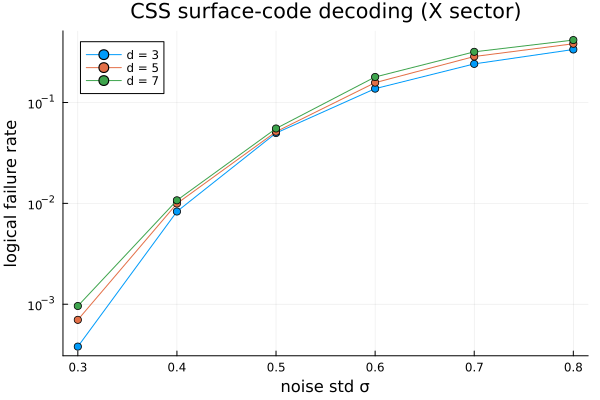

In [7]:
p = plot(
    xlabel = "noise std σ",
    ylabel = "logical failure rate",
    title = "CSS surface-code decoding ($(basis) sector)",
    legend = :topleft,
    yscale = :log10,
)

for distance in distances
    plot!(p, sigmas * sqrt(2 * pi), failure_rates[distance]; marker = :circle, label = "d = $(distance)")
end
p